# Block 16 — Risk-Targeted Leverage of the Systemic-Risk-Controlled Architecture

## Purpose

Blocks 14–15 established that the daily correlation + VIX systemic-risk overlay materially improves the risk efficiency of the frozen weekly sector strategy.

Block 16 asks:

> **Can modest, risk-targeted leverage convert that improved risk efficiency into higher absolute returns without destroying the drawdown advantage?**

This block does **not** alter the sector signal, the Block 14 systemic-risk trigger, or the Block 15 re-risking logic.

It applies leverage only at the **portfolio level**.

---

## Architectures evaluated

1. **Block 14 defensive overlay**
2. **Block 15 Strategic-Breadth re-risking** — preferred enhanced implementation
3. **Block 15 Confirmed-Breadth re-risking** — conservative robustness variant

---

## Leverage experiments

### A. Fixed leverage
Predeclared multipliers:

- 1.00×
- 1.10×
- 1.20×
- 1.30×
- 1.40×
- 1.50×

### B. Risk-targeted leverage
Use lagged realized volatility to scale the portfolio toward:

- 15% annualized volatility
- 18% annualized volatility
- SPY trailing realized volatility

Canonical risk-targeting window:

- **26 trading days**
- leverage estimate is shifted by one trading day
- maximum leverage cap: **1.50×**
- minimum leverage: **0.50×**

### C. Financing costs
Financing is charged only on exposure above 100%.

Canonical financing assumption:

- 4% annualized funding rate

Robustness:

- 2%
- 4%
- 6%

Transaction costs from Blocks 14–15 remain separate and are reported in a sensitivity table.

---

## Key research question

A leveraged defensive architecture is attractive only if it:

- materially raises CAGR and terminal wealth,
- preserves Sharpe / Sortino,
- keeps maximum drawdown materially below the unprotected State-Dependent portfolio,
- does not require extreme leverage,
- remains robust to financing costs.

No signal parameters are optimized.


In [1]:
# ============================================================
# BLOCK 16.1 — ENVIRONMENT & PROJECT PATHS
# ============================================================

from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

PROJECT_ROOT = Path(
    r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/"
    r"State-Dependent U.S. Equity Sector Rotation - "
    r"A Systematic Framework for Trend-Based Active Sector Allocation"
)

if not PROJECT_ROOT.exists():
    alt = Path(
        r"/content/drive/MyDrive/Colab Notebooks/Sector Rotation Model/"
        r"State-Dependent U.S. Equity Sector Rotation - "
        r"A Systematic Framework for Trend-Based Active Sector Allocation"
    )
    if alt.exists():
        PROJECT_ROOT = alt

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(PROJECT_ROOT)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MANIFEST_DIR = PROJECT_ROOT / "manifests"

for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PPY = 252

print("Project root:", PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation


In [2]:
# ============================================================
# BLOCK 16.2 — LOAD BLOCK 14 / 15 OUTPUTS
# ============================================================

def load_manifest(filename):
    path = MANIFEST_DIR / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block14 = load_manifest("block_14_daily_correlation_vix_overlay.json")
block15 = load_manifest("block_15_asymmetric_systemic_risk_rerisking.json")

def resolve_existing(path_string):
    p = Path(path_string)
    if p.exists():
        return p
    hits = list(PROJECT_ROOT.rglob(p.name))
    if hits:
        return hits[0]
    raise FileNotFoundError(p)

RETURNS14_PATH = resolve_existing(block14["saved_files"]["daily_returns"])
RETURNS15_PATH = resolve_existing(block15["saved_files"]["daily_returns"])
EXPOSURES15_PATH = resolve_existing(block15["saved_files"]["daily_exposures"])

returns14 = pd.read_parquet(RETURNS14_PATH).copy()
returns15 = pd.read_parquet(RETURNS15_PATH).copy()
exposures15 = pd.read_parquet(EXPOSURES15_PATH).copy()

for df in [returns14, returns15, exposures15]:
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.sort_index(inplace=True)

print("Block 14 returns:", RETURNS14_PATH)
print("Block 15 returns:", RETURNS15_PATH)
print("Block 15 exposures:", EXPOSURES15_PATH)
print("Columns:", list(returns15.columns))


Block 14 returns: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/outputs/tables/block_14_daily_overlay_returns.parquet
Block 15 returns: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/outputs/tables/block_15_daily_returns.parquet
Block 15 exposures: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/outputs/tables/block_15_daily_exposures.parquet
Columns: ['SPY', 'State_Dependent_Daily_Reconstructed', 'State_Dependent_VIX_Corr_Overlay', 'Block15_StrategicBreadth', 'Block15_ConfirmedBreadth']


In [3]:
# ============================================================
# BLOCK 16.3 — DEFINE BASE ARCHITECTURES
# ============================================================

required = [
    "State_Dependent_VIX_Corr_Overlay",
    "Block15_StrategicBreadth",
    "Block15_ConfirmedBreadth",
]

for c in required:
    if c not in returns15.columns and c not in returns14.columns:
        raise KeyError(f"Missing required return series: {c}")

base_returns = pd.DataFrame(index=returns15.index)

base_returns["Block14"] = (
    returns14["State_Dependent_VIX_Corr_Overlay"]
    .reindex(base_returns.index)
)

base_returns["Block15_StrategicBreadth"] = (
    returns15["Block15_StrategicBreadth"]
)

base_returns["Block15_ConfirmedBreadth"] = (
    returns15["Block15_ConfirmedBreadth"]
)

if "SPY" in returns15.columns:
    base_returns["SPY"] = returns15["SPY"]
elif "SPY" in returns14.columns:
    base_returns["SPY"] = returns14["SPY"]

base_returns = base_returns.dropna()

print("Base comparison range:", base_returns.index.min(), "to", base_returns.index.max())
print("Observations:", len(base_returns))


Base comparison range: 2019-06-25 00:00:00 to 2026-08-24 00:00:00
Observations: 1801


In [4]:
# ============================================================
# BLOCK 16.4 — PERFORMANCE HELPERS
# ============================================================

def max_drawdown(r):
    wealth = (1 + r.dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def perf_stats(r):
    r = r.dropna()
    wealth = (1 + r).cumprod()
    years = (r.index[-1] - r.index[0]).days / 365.2425

    cagr = (
        wealth.iloc[-1] ** (1 / years) - 1
        if years > 0 else np.nan
    )

    vol = r.std(ddof=1) * np.sqrt(PPY)

    sharpe = (
        r.mean() / r.std(ddof=1) * np.sqrt(PPY)
        if r.std(ddof=1) > 0 else np.nan
    )

    downside = r[r < 0].std(ddof=1) * np.sqrt(PPY)

    sortino = (
        r.mean() * PPY / downside
        if downside > 0 else np.nan
    )

    mdd = max_drawdown(r)

    calmar = (
        cagr / abs(mdd)
        if mdd < 0 else np.nan
    )

    return pd.Series({
        "Terminal_Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Annualized_Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max_Drawdown": mdd,
        "Calmar": calmar,
    })

base_performance = base_returns.apply(perf_stats).T
display(base_performance)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar
Block14,2.413896,0.130874,0.132552,0.996949,1.295964,-0.163955,0.798231
Block15_StrategicBreadth,2.434767,0.132234,0.132789,1.004485,1.306753,-0.163955,0.806523
Block15_ConfirmedBreadth,2.424617,0.131574,0.132769,1.000209,1.300998,-0.163955,0.802498
SPY,2.879664,0.159066,0.196955,0.850332,1.045185,-0.337173,0.471764


In [5]:
# ============================================================
# BLOCK 16.5 — FIXED-LEVERAGE ENGINE
# ============================================================

FIXED_LEVERAGE = [1.00, 1.10, 1.20, 1.30, 1.40, 1.50]
CANONICAL_FINANCING_RATE = 0.04

def apply_fixed_leverage(r, leverage, financing_rate):
    r = pd.Series(r).copy()

    financing_cost = (
        max(leverage - 1.0, 0.0)
        * financing_rate
        / PPY
    )

    leveraged = (
        leverage * r
        - financing_cost
    )

    return leveraged

fixed_results = {}
fixed_rows = []

for architecture in [
    "Block14",
    "Block15_StrategicBreadth",
    "Block15_ConfirmedBreadth",
]:
    for lev in FIXED_LEVERAGE:
        name = f"{architecture}_{lev:.2f}x"

        r = apply_fixed_leverage(
            base_returns[architecture],
            lev,
            CANONICAL_FINANCING_RATE,
        )

        fixed_results[name] = r

        s = perf_stats(r)
        s["Architecture"] = architecture
        s["Leverage"] = lev
        s["Financing_Rate"] = CANONICAL_FINANCING_RATE
        fixed_rows.append(s)

fixed_summary = (
    pd.DataFrame(fixed_rows)
    .set_index(["Architecture", "Leverage"])
)

display(fixed_summary)


Terminal_Wealth      CAGR  \
Architecture             Leverage                              
Block14                  1.0              2.413896  0.130874   
                         1.1              2.544198  0.139202   
                         1.2              2.678123  0.147388   
                         1.3              2.815509  0.155427   
                         1.4              2.956168  0.163315   
                         1.5              3.099891  0.171049   
Block15_StrategicBreadth 1.0              2.434767  0.132234   
                         1.1              2.568342  0.140705   
                         1.2              2.705787  0.149035   
                         1.3              2.846944  0.157219   
                         1.4              2.991633  0.165253   
                         1.5              3.139647  0.173133   
Block15_ConfirmedBreadth 1.0              2.424617  0.131574   
                         1.1              2.556572  0.139974   
                         1.2              2.692270  0.148232   
                         1.3              2.831548  0.156344   
                         1.4              2.974221  0.164304   
                         1.5              3.120082  0.172110   

                                   Annualized_Volatility    Sharpe   Sortino  \
Architecture             Leverage                                              
Block14                  1.0                    0.132552  0.996949  1.295964   
                         1.1                    0.145807  0.969516  1.260300   
                         1.2                    0.159063  0.946655  1.230581   
                         1.3                    0.172318  0.927311  1.205435   
                         1.4                    0.185573  0.910730  1.183877   
                         1.5                    0.198828  0.896360  1.165194   
Block15_StrategicBreadth 1.0                    0.132789  1.004485  1.306753   
                         1.1                    0.146068  0.977100  1.271123   
                         1.2                    0.159347  0.954280  1.241433   
                         1.3                    0.172626  0.934970  1.216313   
                         1.4                    0.185904  0.918419  1.194776   
                         1.5                    0.199183  0.904075  1.176111   
Block15_ConfirmedBreadth 1.0                    0.132769  1.000209  1.300998   
                         1.1                    0.146046  0.972820  1.265368   
                         1.2                    0.159323  0.949997  1.235678   
                         1.3                    0.172600  0.930684  1.210558   
                         1.4                    0.185877  0.914131  1.189021   
                         1.5                    0.199154  0.899784  1.170356   

                                   Max_Drawdown    Calmar  Financing_Rate  
Architecture             Leverage                                          
Block14                  1.0          -0.163955  0.798231            0.04  
                         1.1          -0.179403  0.775920            0.04  
                         1.2          -0.194617  0.757325            0.04  
                         1.3          -0.209599  0.741546            0.04  
                         1.4          -0.224352  0.727942            0.04  
                         1.5          -0.238879  0.716046            0.04  
Block15_StrategicBreadth 1.0          -0.163955  0.806523            0.04  
                         1.1          -0.179403  0.784296            0.04  
                         1.2          -0.194617  0.765787            0.04  
                         1.3          -0.209599  0.750095            0.04  
                         1.4          -0.224352  0.736580            0.04  
                         1.5          -0.238879  0.724773            0.04  
Block15_ConfirmedBreadth 1.0          -0.163955  0.802498            0.04  
             

In [6]:
# ============================================================
# BLOCK 16.6 — LAGGED REALIZED-VOLATILITY SCALING
# ============================================================

VOL_LOOKBACK = 26
MIN_LEVERAGE = 0.50
MAX_LEVERAGE = 1.50
VOL_TARGETS = [0.15, 0.18]

def lagged_realized_vol(r, lookback=26):
    return (
        r.rolling(
            lookback,
            min_periods=lookback,
        )
        .std(ddof=1)
        .shift(1)
        * np.sqrt(PPY)
    )

def risk_targeted_return(
    r,
    target_vol,
    financing_rate,
    lookback=26,
    min_leverage=0.50,
    max_leverage=1.50,
):
    r = pd.Series(r).copy()

    ex_ante_vol = lagged_realized_vol(
        r,
        lookback=lookback,
    )

    leverage = (
        target_vol / ex_ante_vol
    ).clip(
        lower=min_leverage,
        upper=max_leverage,
    )

    financing = (
        (leverage - 1.0)
        .clip(lower=0.0)
        * financing_rate
        / PPY
    )

    scaled_return = (
        leverage * r
        - financing
    )

    result = pd.DataFrame({
        "base_return": r,
        "ex_ante_vol": ex_ante_vol,
        "leverage": leverage,
        "financing_cost": financing,
        "scaled_return": scaled_return,
    }).dropna()

    return result

vol_target_results = {}
vol_target_rows = []

for architecture in [
    "Block14",
    "Block15_StrategicBreadth",
    "Block15_ConfirmedBreadth",
]:
    for target in VOL_TARGETS:
        key = f"{architecture}_VolTarget_{int(target*100)}"

        df = risk_targeted_return(
            base_returns[architecture],
            target_vol=target,
            financing_rate=CANONICAL_FINANCING_RATE,
            lookback=VOL_LOOKBACK,
            min_leverage=MIN_LEVERAGE,
            max_leverage=MAX_LEVERAGE,
        )

        vol_target_results[key] = df

        s = perf_stats(df["scaled_return"])
        s["Architecture"] = architecture
        s["Target_Vol"] = target
        s["Average_Leverage"] = df["leverage"].mean()
        s["Median_Leverage"] = df["leverage"].median()
        s["Maximum_Leverage"] = df["leverage"].max()
        s["Minimum_Leverage"] = df["leverage"].min()
        vol_target_rows.append(s)

vol_target_summary = (
    pd.DataFrame(vol_target_rows)
    .set_index(["Architecture", "Target_Vol"])
)

display(vol_target_summary)


Terminal_Wealth      CAGR  \
Architecture             Target_Vol                              
Block14                  0.15               2.486435  0.137629   
                         0.18               2.758961  0.154503   
Block15_StrategicBreadth 0.15               2.499337  0.138463   
                         0.18               2.767241  0.154993   
Block15_ConfirmedBreadth 0.15               2.491269  0.137942   
                         0.18               2.756521  0.154358   

                                     Annualized_Volatility    Sharpe  \
Architecture             Target_Vol                                    
Block14                  0.15                     0.152512  0.924611   
                         0.18                     0.169902  0.933516   
Block15_StrategicBreadth 0.15                     0.152406  0.929976   
                         0.18                     0.169907  0.936000   
Block15_ConfirmedBreadth 0.15                     0.152401  0.926984   
                         0.18                     0.169901  0.932780   

                                      Sortino  Max_Drawdown    Calmar  \
Architecture             Target_Vol                                     
Block14                  0.15        1.224784     -0.161657  0.851364   
                         0.18        1.237494     -0.183264  0.843062   
Block15_StrategicBreadth 0.15        1.232773     -0.161657  0.856522   
                         0.18        1.240849     -0.183264  0.845735   
Block15_ConfirmedBreadth 0.15        1.228774     -0.161657  0.853300   
                         0.18        1.236538     -0.183264  0.842273   

                                     Average_Leverage  Median_Leverage  \
Architecture             Target_Vol                                      
Block14                  0.15                1.219610         1.311161   
                         0.18                1.333437         1.500000   
Block15_StrategicBreadth 0.15                1.218384         1.308589   
                         0.18                1.332526         1.500000   
Block15_ConfirmedBreadth 0.15                1.218420         1.308589   
                         0.18                1.332570         1.500000   

                                     Maximum_Leverage  Minimum_Leverage  
Architecture             Target_Vol                                      
Block14                  0.15                     1.5          0.590969  
                         0.18                     1.5          0.709163  
Block15_StrategicBreadth 0.15                     1.5          0.590969  
                         0.18                     1.5          0.709163  
Block15_ConfirmedBreadth 0.15                     1.5          0.590969  
                         0.18                     1.5          0.709163

In [7]:
# ============================================================
# BLOCK 16.7 — SPY-VOLATILITY-MATCHED SCALING
# ============================================================

if "SPY" not in base_returns.columns:
    raise KeyError("SPY return series is required for volatility matching.")

spy_trailing_vol = lagged_realized_vol(
    base_returns["SPY"],
    lookback=VOL_LOOKBACK,
)

spy_match_results = {}
spy_match_rows = []

for architecture in [
    "Block14",
    "Block15_StrategicBreadth",
    "Block15_ConfirmedBreadth",
]:
    r = base_returns[architecture]

    strategy_vol = lagged_realized_vol(
        r,
        lookback=VOL_LOOKBACK,
    )

    leverage = (
        spy_trailing_vol / strategy_vol
    ).clip(
        lower=MIN_LEVERAGE,
        upper=MAX_LEVERAGE,
    )

    financing = (
        (leverage - 1.0)
        .clip(lower=0.0)
        * CANONICAL_FINANCING_RATE
        / PPY
    )

    scaled = (
        leverage * r
        - financing
    )

    df = pd.DataFrame({
        "base_return": r,
        "strategy_vol": strategy_vol,
        "spy_vol": spy_trailing_vol,
        "leverage": leverage,
        "financing_cost": financing,
        "scaled_return": scaled,
    }).dropna()

    spy_match_results[architecture] = df

    s = perf_stats(df["scaled_return"])
    s["Architecture"] = architecture
    s["Average_Leverage"] = df["leverage"].mean()
    s["Median_Leverage"] = df["leverage"].median()
    s["Maximum_Leverage"] = df["leverage"].max()
    s["Minimum_Leverage"] = df["leverage"].min()
    spy_match_rows.append(s)

spy_match_summary = (
    pd.DataFrame(spy_match_rows)
    .set_index("Architecture")
)

display(spy_match_summary)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar,Average_Leverage,Median_Leverage,Maximum_Leverage,Minimum_Leverage
Architecture,,,,,,,,,,,
Block14,2.567752,0.142823,0.165190,0.893656,1.136659,-0.217795,0.655771,1.201010,1.180366,1.5,0.702064
Block15_StrategicBreadth,2.594259,0.144486,0.165586,0.900723,1.146246,-0.217795,0.663406,1.200883,1.180366,1.5,0.702064
Block15_ConfirmedBreadth,2.583147,0.143791,0.165580,0.897068,1.141545,-0.217795,0.660214,1.200932,1.180366,1.5,0.702064


In [8]:
# ============================================================
# BLOCK 16.8 — FINANCING-COST ROBUSTNESS
# ============================================================

FINANCING_RATES = [0.02, 0.04, 0.06]

rows = []

for financing_rate in FINANCING_RATES:
    for architecture in [
        "Block14",
        "Block15_StrategicBreadth",
        "Block15_ConfirmedBreadth",
    ]:
        for lev in [1.20, 1.30, 1.40, 1.50]:

            r = apply_fixed_leverage(
                base_returns[architecture],
                lev,
                financing_rate,
            )

            s = perf_stats(r)

            rows.append({
                "Architecture": architecture,
                "Leverage": lev,
                "Financing_Rate": financing_rate,
                **s.to_dict(),
            })

financing_sensitivity = (
    pd.DataFrame(rows)
    .set_index([
        "Architecture",
        "Leverage",
        "Financing_Rate",
    ])
)

display(financing_sensitivity)


Terminal_Wealth      CAGR  \
Architecture             Leverage Financing_Rate                              
Block14                  1.2      0.02                   2.755749  0.151973   
                         1.3      0.02                   2.938800  0.162359   
                         1.4      0.02                   3.130012  0.172630   
                         1.5      0.02                   3.329408  0.182781   
Block15_StrategicBreadth 1.2      0.02                   2.784214  0.153626   
                         1.3      0.02                   2.971612  0.164162   
                         1.4      0.02                   3.167562  0.174583   
                         1.5      0.02                   3.372107  0.184886   
Block15_ConfirmedBreadth 1.2      0.02                   2.770305  0.152820   
                         1.3      0.02                   2.955541  0.163281   
                         1.4      0.02                   3.149127  0.173627   
                         1.5      0.02                   3.351093  0.183853   
Block14                  1.2      0.04                   2.678123  0.147388   
                         1.3      0.04                   2.815509  0.155427   
                         1.4      0.04                   2.956168  0.163315   
                         1.5      0.04                   3.099891  0.171049   
Block15_StrategicBreadth 1.2      0.04                   2.705787  0.149035   
                         1.3      0.04                   2.846944  0.157219   
                         1.4      0.04                   2.991633  0.165253   
                         1.5      0.04                   3.139647  0.173133   
Block15_ConfirmedBreadth 1.2      0.04                   2.692270  0.148232   
                         1.3      0.04                   2.831548  0.156344   
                         1.4      0.04                   2.974221  0.164304   
                         1.5      0.04                   3.120082  0.172110   
Block14                  1.2      0.06                   2.602683  0.142822   
                         1.3      0.06                   2.697387  0.148536   
                         1.4      0.06                   2.791973  0.154074   
                         1.5      0.06                   2.886188  0.159432   
Block15_StrategicBreadth 1.2      0.06                   2.629568  0.144462   
                         1.3      0.06                   2.727505  0.150318   
                         1.4      0.06                   2.825470  0.155997   
                         1.5      0.06                   2.923205  0.161496   
Block15_ConfirmedBreadth 1.2      0.06                   2.616431  0.143662   
                         1.3      0.06                   2.712753  0.149447   
                         1.4      0.06                   2.809025  0.155055   
                         1.5      0.06                   2.904987  0.160483   

                                                  Annualized_Volatility  \
Architecture             Leverage Financing_Rate                          
Block14                  1.2      0.02                         0.159063   
                         1.3      0.02                         0.172318   
                         1.4      0.02                         0.185573   
                         1.5      0.02                         0.198828   
Block15_StrategicBreadth 1.2      0.02                         0.159347   
                         1.3      0.02                         0.172626   
                         1.4      0.02                         0.185904   
                         1.5      0.02                         0.199183   
Block15_ConfirmedBreadth 1.2      0.02                         0.159323   
                         1.3      0.02                         0.172600   
                         1.4      0.02                         0.185877   
                         1.5      0.02                         0.199154 

In [9]:
# ============================================================
# BLOCK 16.9 — LEVERAGE-TURNOVER COST
# ============================================================

def leverage_turnover(leverage):
    # One-way turnover caused by changing only the scalar leverage sleeve.
    return leverage.diff().abs().fillna(0.0)

TRANSACTION_COST_BPS = [0, 5, 10, 20]

cost_rows = []

for architecture, df in spy_match_results.items():

    lev_turn = leverage_turnover(df["leverage"])

    for bps in TRANSACTION_COST_BPS:
        net = (
            df["scaled_return"]
            - lev_turn * (bps / 10000.0)
        )

        s = perf_stats(net)

        cost_rows.append({
            "Architecture": architecture,
            "Cost_bps": bps,
            "Annualized_Leverage_OneWay_Turnover":
                lev_turn.mean() * PPY,
            **s.to_dict(),
        })

leverage_cost_sensitivity = (
    pd.DataFrame(cost_rows)
    .set_index(["Architecture", "Cost_bps"])
)

display(leverage_cost_sensitivity)


Annualized_Leverage_OneWay_Turnover  \
Architecture             Cost_bps                                        
Block14                  0                                    5.101225   
                         5                                    5.101225   
                         10                                   5.101225   
                         20                                   5.101225   
Block15_StrategicBreadth 0                                    5.098681   
                         5                                    5.098681   
                         10                                   5.098681   
                         20                                   5.098681   
Block15_ConfirmedBreadth 0                                    5.101013   
                         5                                    5.101013   
                         10                                   5.101013   
                         20                                   5.101013   

                                   Terminal_Wealth      CAGR  \
Architecture             Cost_bps                              
Block14                  0                2.567752  0.142823   
                         5                2.522048  0.139922   
                         10               2.477155  0.137027   
                         20               2.389748  0.131259   
Block15_StrategicBreadth 0                2.594259  0.144486   
                         5                2.548106  0.141582   
                         10               2.502772  0.138684   
                         20               2.414504  0.132911   
Block15_ConfirmedBreadth 0                2.583147  0.143791   
                         5                2.537170  0.140887   
                         10               2.492010  0.137990   
                         20               2.404083  0.132217   

                                   Annualized_Volatility    Sharpe   Sortino  \
Architecture             Cost_bps                                              
Block14                  0                      0.165190  0.893656  1.136659   
                         5                      0.165192  0.878202  1.117106   
                         10                     0.165195  0.862747  1.097545   
                         20                     0.165202  0.831832  1.058448   
Block15_StrategicBreadth 0                      0.165586  0.900723  1.146246   
                         5                      0.165588  0.885314  1.126742   
                         10                     0.165591  0.869903  1.107230   
                         20                     0.165598  0.839076  1.068232   
Block15_ConfirmedBreadth 0                      0.165580  0.897068  1.141545   
                         5                      0.165582  0.881651  1.122032   
                         10                     0.165585  0.866233  1.102511   
                         20                     0.165592  0.835391  1.063495   

                                   Max_Drawdown    Calmar  
Architecture             Cost_bps                          
Block14                  0            -0.217795  0.655771  
                         5            -0.217983  0.641893  
                         10           -0.218171  0.628072  
                         20           -0.218547  0.600601  
Block15_StrategicBreadth 0            -0.217795  0.663406  
                         5            -0.217983  0.649508  
                         10           -0.218171  0.635668  
                         20           -0.218547  0.608158  
Block15_ConfirmedBreadth 0            -0.217795  0.660214  
                         5            -0.217983  0.646321  
                         10           -0.218171  0.632485  
                         20           -0.218547  0.604985

In [10]:
# ============================================================
# BLOCK 16.10 — RISK / REWARD FRONTIER
# ============================================================

frontier_rows = []

for architecture in [
    "Block14",
    "Block15_StrategicBreadth",
    "Block15_ConfirmedBreadth",
]:
    for lev in FIXED_LEVERAGE:

        idx = (architecture, lev)
        row = fixed_summary.loc[idx]

        frontier_rows.append({
            "Architecture": architecture,
            "Leverage": lev,
            "CAGR": row["CAGR"],
            "Annualized_Volatility":
                row["Annualized_Volatility"],
            "Sharpe": row["Sharpe"],
            "Max_Drawdown": row["Max_Drawdown"],
            "Calmar": row["Calmar"],
        })

frontier = pd.DataFrame(frontier_rows)

display(frontier)


,Architecture,Leverage,CAGR,Annualized_Volatility,Sharpe,Max_Drawdown,Calmar
0,Block14,1.0,0.130874,0.132552,0.996949,-0.163955,0.798231
1,Block14,1.1,0.139202,0.145807,0.969516,-0.179403,0.775920
2,Block14,1.2,0.147388,0.159063,0.946655,-0.194617,0.757325
3,Block14,1.3,0.155427,0.172318,0.927311,-0.209599,0.741546
4,Block14,1.4,0.163315,0.185573,0.910730,-0.224352,0.727942
5,Block14,1.5,0.171049,0.198828,0.896360,-0.238879,0.716046
6,Block15_StrategicBreadth,1.0,0.132234,0.132789,1.004485,-0.163955,0.806523
7,Block15_StrategicBreadth,1.1,0.140705,0.146068,0.977100,-0.179403,0.784296
8,Block15_StrategicBreadth,1.2,0.149035,0.159347,0.954280,-0.194617,0.765787
9,Block15_StrategicBreadth,1.3,0.157219,0.172626,0.934970,-0.209599,0.750095


In [11]:
# ============================================================
# BLOCK 16.11 — DECISION TABLE
# ============================================================

# Primary candidates:
# - fixed 1.20x / 1.30x / 1.40x
# - 15% vol target
# - 18% vol target
# - SPY-vol matched

decision_rows = []

for architecture in [
    "Block14",
    "Block15_StrategicBreadth",
    "Block15_ConfirmedBreadth",
]:
    for lev in [1.20, 1.30, 1.40]:

        r = apply_fixed_leverage(
            base_returns[architecture],
            lev,
            CANONICAL_FINANCING_RATE,
        )

        s = perf_stats(r)

        decision_rows.append({
            "Architecture": architecture,
            "Scaling_Rule": f"Fixed_{lev:.2f}x",
            "Average_Leverage": lev,
            **s.to_dict(),
        })

    for target in VOL_TARGETS:
        key = f"{architecture}_VolTarget_{int(target*100)}"
        df = vol_target_results[key]
        s = perf_stats(df["scaled_return"])

        decision_rows.append({
            "Architecture": architecture,
            "Scaling_Rule": f"VolTarget_{int(target*100)}pct",
            "Average_Leverage": df["leverage"].mean(),
            **s.to_dict(),
        })

    df = spy_match_results[architecture]
    s = perf_stats(df["scaled_return"])

    decision_rows.append({
        "Architecture": architecture,
        "Scaling_Rule": "SPY_Vol_Matched",
        "Average_Leverage": df["leverage"].mean(),
        **s.to_dict(),
    })

decision_table = (
    pd.DataFrame(decision_rows)
    .set_index(["Architecture", "Scaling_Rule"])
)

display(decision_table)


Average_Leverage  Terminal_Wealth  \
Architecture             Scaling_Rule                                         
Block14                  Fixed_1.20x              1.200000         2.678123   
                         Fixed_1.30x              1.300000         2.815509   
                         Fixed_1.40x              1.400000         2.956168   
                         VolTarget_15pct          1.219610         2.486435   
                         VolTarget_18pct          1.333437         2.758961   
                         SPY_Vol_Matched          1.201010         2.567752   
Block15_StrategicBreadth Fixed_1.20x              1.200000         2.705787   
                         Fixed_1.30x              1.300000         2.846944   
                         Fixed_1.40x              1.400000         2.991633   
                         VolTarget_15pct          1.218384         2.499337   
                         VolTarget_18pct          1.332526         2.767241   
                         SPY_Vol_Matched          1.200883         2.594259   
Block15_ConfirmedBreadth Fixed_1.20x              1.200000         2.692270   
                         Fixed_1.30x              1.300000         2.831548   
                         Fixed_1.40x              1.400000         2.974221   
                         VolTarget_15pct          1.218420         2.491269   
                         VolTarget_18pct          1.332570         2.756521   
                         SPY_Vol_Matched          1.200932         2.583147   

                                              CAGR  Annualized_Volatility  \
Architecture             Scaling_Rule                                       
Block14                  Fixed_1.20x      0.147388               0.159063   
                         Fixed_1.30x      0.155427               0.172318   
                         Fixed_1.40x      0.163315               0.185573   
                         VolTarget_15pct  0.137629               0.152512   
                         VolTarget_18pct  0.154503               0.169902   
                         SPY_Vol_Matched  0.142823               0.165190   
Block15_StrategicBreadth Fixed_1.20x      0.149035               0.159347   
                         Fixed_1.30x      0.157219               0.172626   
                         Fixed_1.40x      0.165253               0.185904   
                         VolTarget_15pct  0.138463               0.152406   
                         VolTarget_18pct  0.154993               0.169907   
                         SPY_Vol_Matched  0.144486               0.165586   
Block15_ConfirmedBreadth Fixed_1.20x      0.148232               0.159323   
                         Fixed_1.30x      0.156344               0.172600   
                         Fixed_1.40x      0.164304               0.185877   
                         VolTarget_15pct  0.137942               0.152401   
                         VolTarget_18pct  0.154358               0.169901   
                         SPY_Vol_Matched  0.143791               0.165580   

                                            Sharpe   Sortino  Max_Drawdown  \
Architecture             Scaling_Rule                                        
Block14                  Fixed_1.20x      0.946655  1.230581     -0.194617   
                         Fixed_1.30x      0.927311  1.205435     -0.209599   
                         Fixed_1.40x      0.910730  1.183877     -0.224352   
                         VolTarget_15pct  0.924611  1.224784     -0.161657   
                         VolTarget_18pct  0.933516  1.237494     -0.183264   
                         SPY_Vol_Matched  0.893656  1.136659     -0.217795   
Block15_StrategicBreadth Fixed_1.20x      0.954280  1.241433     -0.194617   
                         Fixed_1.30x      0.934970  1.216313     -0.209599   
                         Fixed_1.40x      0.918419  1.194776     -0.224352   
                         VolTarget_15pct  0.929976  1.232773  

In [12]:
# ============================================================
# BLOCK 16.12 — PREDECLARED IMPLEMENTATION GUARDRAILS
# ============================================================

# A leveraged implementation is considered attractive only if:
# 1) CAGR exceeds the unlevered Block 15 Strategic-Breadth implementation.
# 2) Sharpe remains >= 0.95.
# 3) Maximum drawdown remains better than -25%.
# 4) Average leverage remains <= 1.50x.
# 5) Calmar remains >= 0.65.

reference = perf_stats(
    base_returns["Block15_StrategicBreadth"]
)

guardrail_rows = []

for idx, row in decision_table.iterrows():
    guardrail_rows.append({
        "Architecture": idx[0],
        "Scaling_Rule": idx[1],
        "CAGR_Above_Unlevered_Block15":
            row["CAGR"] > reference["CAGR"],
        "Sharpe_Above_0_95":
            row["Sharpe"] >= 0.95,
        "MaxDD_Better_Than_Minus25pct":
            row["Max_Drawdown"] >= -0.25,
        "Average_Leverage_At_Most_1_50x":
            row["Average_Leverage"] <= 1.50,
        "Calmar_Above_0_65":
            row["Calmar"] >= 0.65,
    })

guardrails = (
    pd.DataFrame(guardrail_rows)
    .set_index(["Architecture", "Scaling_Rule"])
)

display(guardrails)


CAGR_Above_Unlevered_Block15  \
Architecture             Scaling_Rule                                    
Block14                  Fixed_1.20x                              True   
                         Fixed_1.30x                              True   
                         Fixed_1.40x                              True   
                         VolTarget_15pct                          True   
                         VolTarget_18pct                          True   
                         SPY_Vol_Matched                          True   
Block15_StrategicBreadth Fixed_1.20x                              True   
                         Fixed_1.30x                              True   
                         Fixed_1.40x                              True   
                         VolTarget_15pct                          True   
                         VolTarget_18pct                          True   
                         SPY_Vol_Matched                          True   
Block15_ConfirmedBreadth Fixed_1.20x                              True   
                         Fixed_1.30x                              True   
                         Fixed_1.40x                              True   
                         VolTarget_15pct                          True   
                         VolTarget_18pct                          True   
                         SPY_Vol_Matched                          True   

                                          Sharpe_Above_0_95  \
Architecture             Scaling_Rule                         
Block14                  Fixed_1.20x                  False   
                         Fixed_1.30x                  False   
                         Fixed_1.40x                  False   
                         VolTarget_15pct              False   
                         VolTarget_18pct              False   
                         SPY_Vol_Matched              False   
Block15_StrategicBreadth Fixed_1.20x                   True   
                         Fixed_1.30x                  False   
                         Fixed_1.40x                  False   
                         VolTarget_15pct              False   
                         VolTarget_18pct              False   
                         SPY_Vol_Matched              False   
Block15_ConfirmedBreadth Fixed_1.20x                  False   
                         Fixed_1.30x                  False   
                         Fixed_1.40x                  False   
                         VolTarget_15pct              False   
                         VolTarget_18pct              False   
                         SPY_Vol_Matched              False   

                                          MaxDD_Better_Than_Minus25pct  \
Architecture             Scaling_Rule                                    
Block14                  Fixed_1.20x                              True   
                         Fixed_1.30x                              True   
                         Fixed_1.40x                              True   
                         VolTarget_15pct                          True   
                         VolTarget_18pct                          True   
                         SPY_Vol_Matched                          True   
Block15_StrategicBreadth Fixed_1.20x                              True   
                         Fixed_1.30x                              True   
                         Fixed_1.40x                              True   
                         VolTarget_15pct                          True   
                         VolTarget_18pct                          True   
                         SPY_Vol_Matched                          True   
Block15_ConfirmedBreadth Fixed_1.20x                              True   
                         Fixed_1.30x                              True   
                         Fixed_1.40x                              True   
                         VolTarget_15pct  

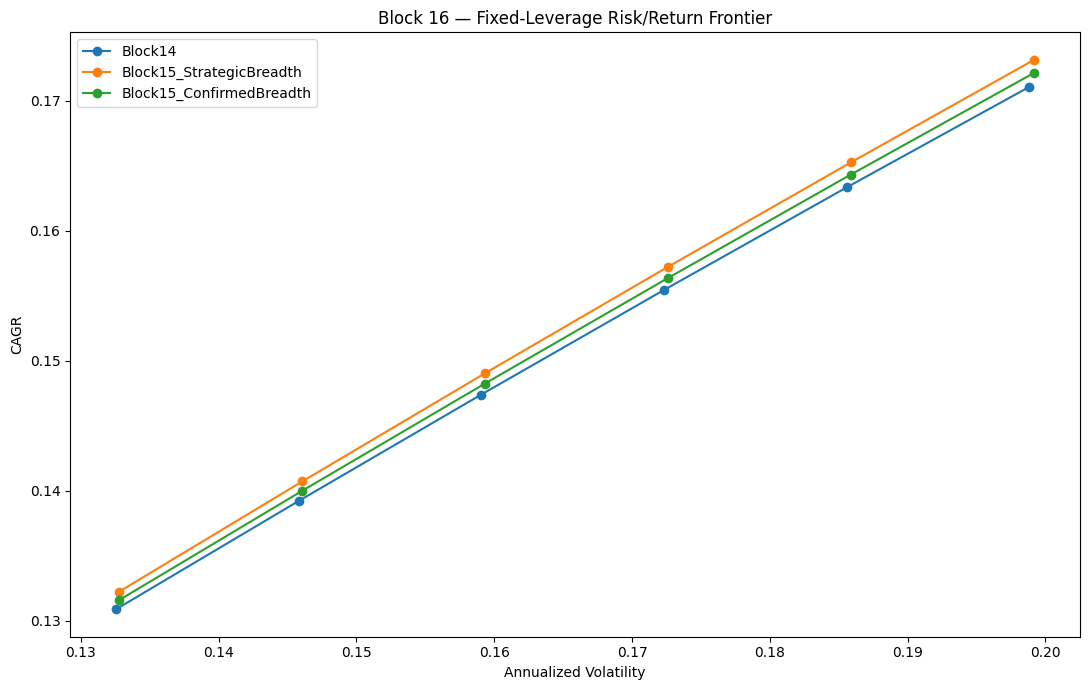

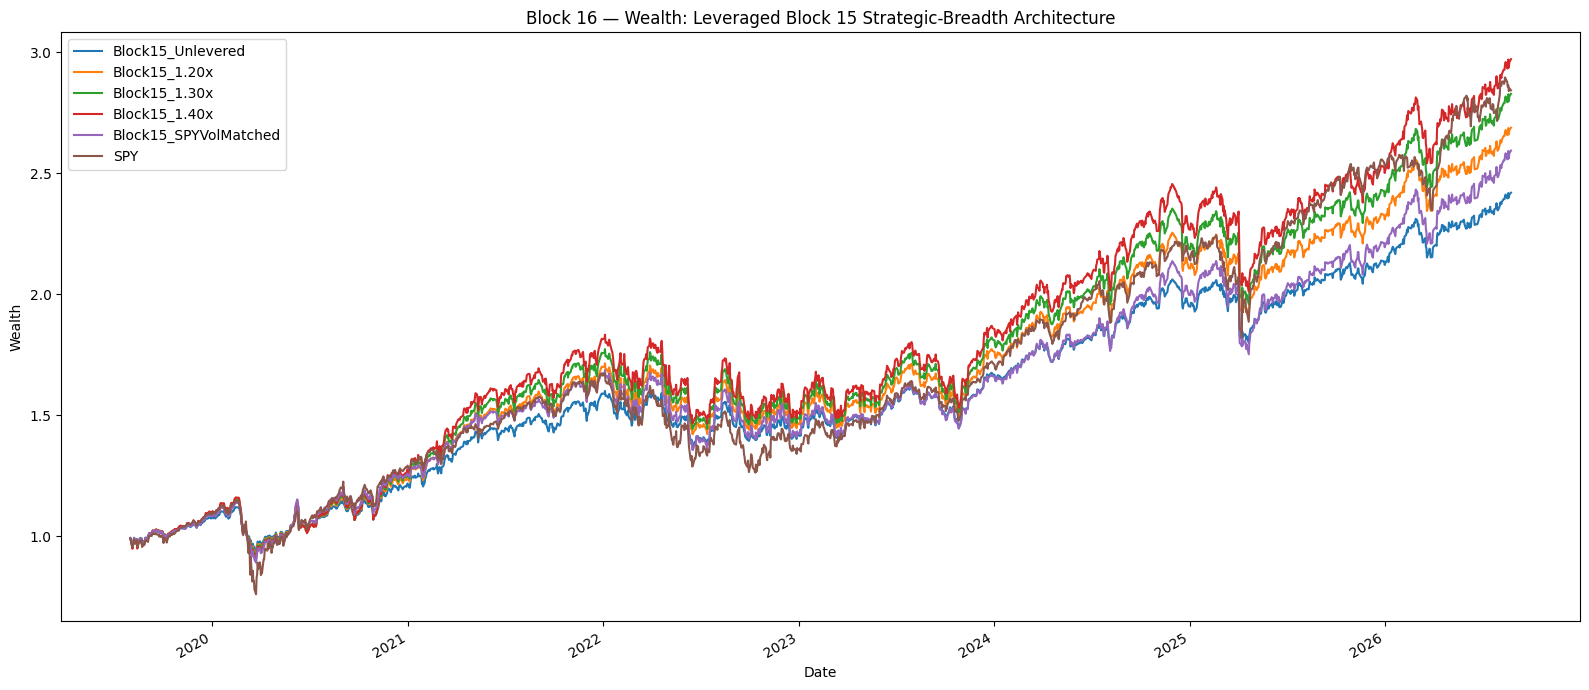

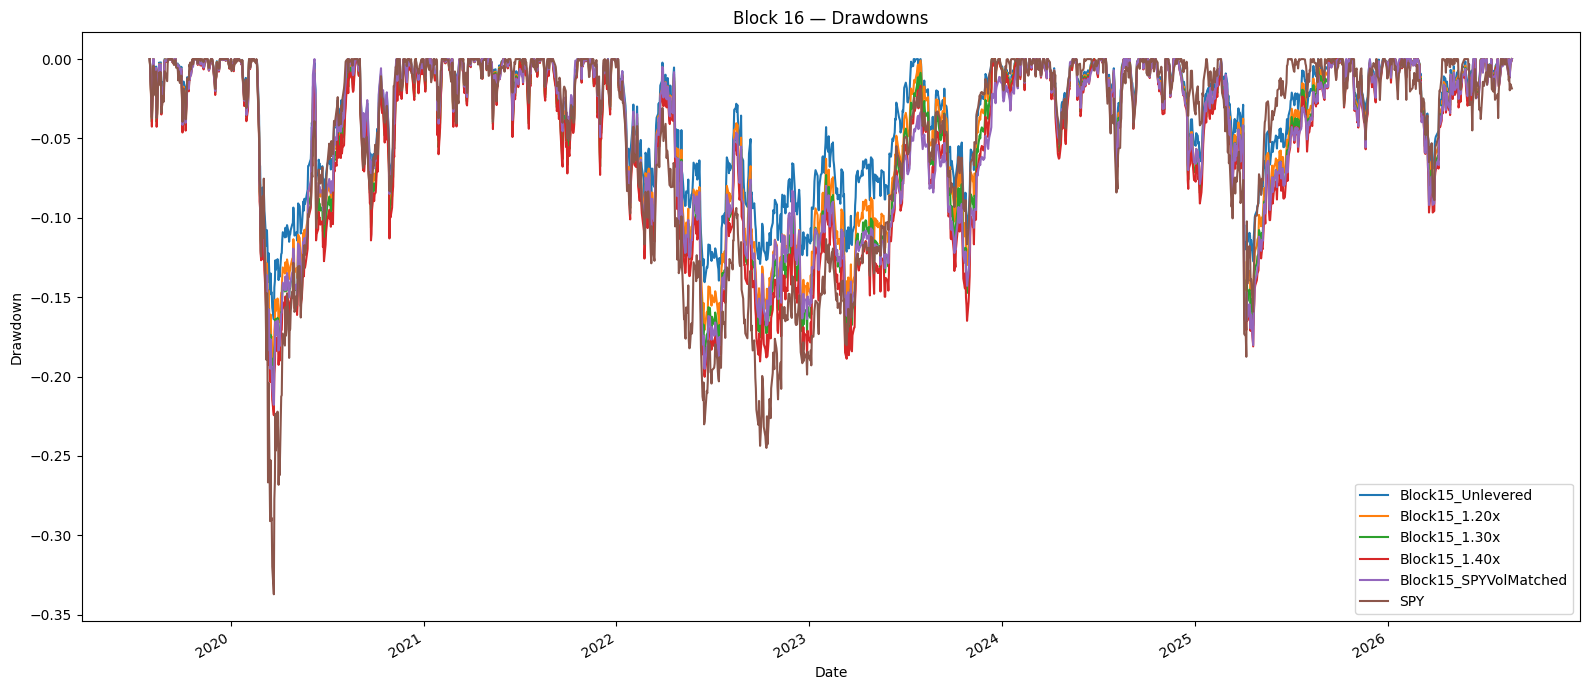

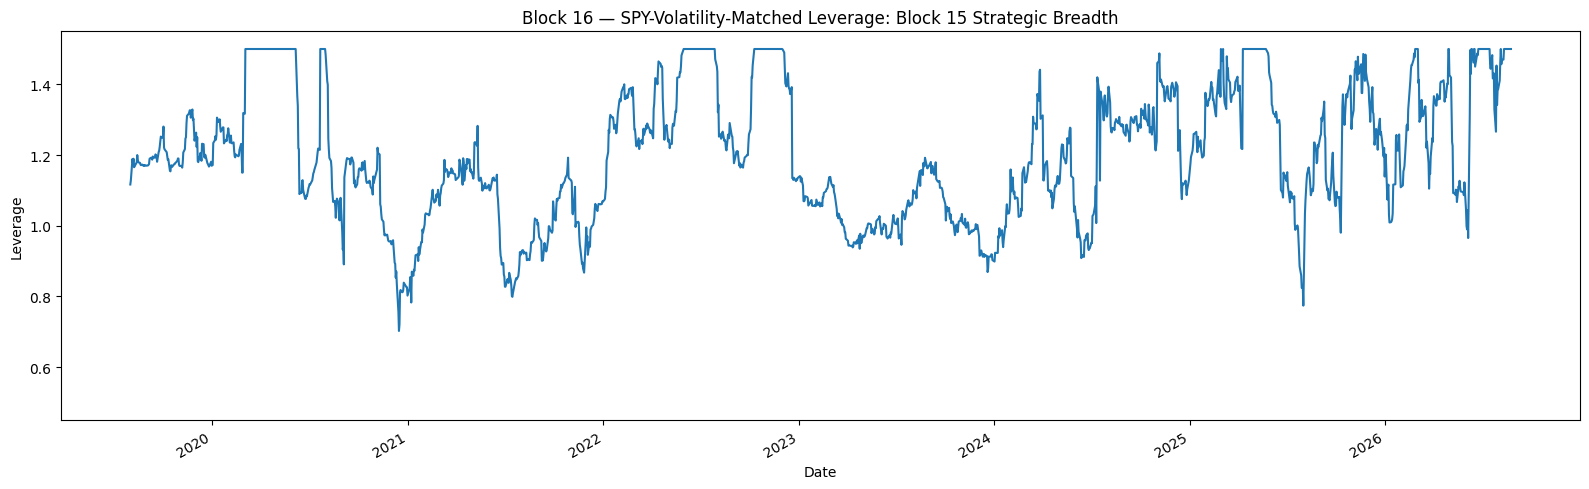

In [13]:
# ============================================================
# BLOCK 16.13 — FIGURES
# ============================================================

# 1) Fixed leverage frontier
fig, ax = plt.subplots(figsize=(11, 7))

for architecture in frontier["Architecture"].unique():
    x = frontier[
        frontier["Architecture"] == architecture
    ]
    ax.plot(
        x["Annualized_Volatility"],
        x["CAGR"],
        marker="o",
        label=architecture,
    )

ax.set_title("Block 16 — Fixed-Leverage Risk/Return Frontier")
ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("CAGR")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_16_fixed_leverage_frontier.png",
    dpi=180,
)
plt.show()

# 2) Wealth for key Block 15 strategic-breadth implementations
key_returns = pd.DataFrame(index=base_returns.index)

key_returns["Block15_Unlevered"] = (
    base_returns["Block15_StrategicBreadth"]
)

for lev in [1.20, 1.30, 1.40]:
    key_returns[f"Block15_{lev:.2f}x"] = (
        apply_fixed_leverage(
            base_returns["Block15_StrategicBreadth"],
            lev,
            CANONICAL_FINANCING_RATE,
        )
    )

spy_match = spy_match_results[
    "Block15_StrategicBreadth"
]["scaled_return"]

key_returns["Block15_SPYVolMatched"] = (
    spy_match.reindex(key_returns.index)
)

if "SPY" in base_returns.columns:
    key_returns["SPY"] = base_returns["SPY"]

key_returns = key_returns.dropna()

wealth = (1 + key_returns).cumprod()

fig, ax = plt.subplots(figsize=(16, 7))
wealth.plot(ax=ax)
ax.set_title(
    "Block 16 — Wealth: Leveraged Block 15 Strategic-Breadth Architecture"
)
ax.set_ylabel("Wealth")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_16_wealth.png",
    dpi=180,
)
plt.show()

# 3) Drawdowns
drawdown = wealth.div(
    wealth.cummax()
).sub(1)

fig, ax = plt.subplots(figsize=(16, 7))
drawdown.plot(ax=ax)
ax.set_title("Block 16 — Drawdowns")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_16_drawdowns.png",
    dpi=180,
)
plt.show()

# 4) SPY-vol matched leverage path
lev = spy_match_results[
    "Block15_StrategicBreadth"
]["leverage"]

fig, ax = plt.subplots(figsize=(16, 5))
lev.plot(ax=ax)
ax.set_title(
    "Block 16 — SPY-Volatility-Matched Leverage: Block 15 Strategic Breadth"
)
ax.set_ylabel("Leverage")
ax.set_ylim(0.45, 1.55)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_16_spy_vol_matched_leverage.png",
    dpi=180,
)
plt.show()


In [14]:
# ============================================================
# BLOCK 16.14 — SAVE OUTPUTS & MANIFEST
# ============================================================

BASE_PATH = TABLE_DIR / "block_16_base_performance.csv"
FIXED_PATH = TABLE_DIR / "block_16_fixed_leverage_summary.csv"
VOL_PATH = TABLE_DIR / "block_16_vol_target_summary.csv"
SPY_MATCH_PATH = TABLE_DIR / "block_16_spy_vol_matched_summary.csv"
FIN_PATH = TABLE_DIR / "block_16_financing_sensitivity.csv"
LEV_COST_PATH = TABLE_DIR / "block_16_leverage_cost_sensitivity.csv"
FRONTIER_PATH = TABLE_DIR / "block_16_risk_reward_frontier.csv"
DECISION_PATH = TABLE_DIR / "block_16_decision_table.csv"
GUARDRAIL_PATH = TABLE_DIR / "block_16_guardrails.csv"

base_performance.to_csv(BASE_PATH)
fixed_summary.to_csv(FIXED_PATH)
vol_target_summary.to_csv(VOL_PATH)
spy_match_summary.to_csv(SPY_MATCH_PATH)
financing_sensitivity.to_csv(FIN_PATH)
leverage_cost_sensitivity.to_csv(LEV_COST_PATH)
frontier.to_csv(FRONTIER_PATH, index=False)
decision_table.to_csv(DECISION_PATH)
guardrails.to_csv(GUARDRAIL_PATH)

SPY_MATCH_RETURNS_PATH = (
    OUTPUT_DIR
    / "block_16_spy_vol_matched_returns.parquet"
)

SPY_MATCH_LEVERAGE_PATH = (
    OUTPUT_DIR
    / "block_16_spy_vol_matched_leverage.parquet"
)

pd.DataFrame({
    k: v["scaled_return"]
    for k, v in spy_match_results.items()
}).to_parquet(
    SPY_MATCH_RETURNS_PATH
)

pd.DataFrame({
    k: v["leverage"]
    for k, v in spy_match_results.items()
}).to_parquet(
    SPY_MATCH_LEVERAGE_PATH
)

manifest = {
    "block": 16,
    "title": "Risk-Targeted Leverage of the Systemic-Risk-Controlled Architecture",
    "research_extension": True,
    "blocks_1_to_15_altered": False,
    "signal_parameters_optimized": False,

    "fixed_leverage_grid": FIXED_LEVERAGE,

    "risk_targeting": {
        "lookback_trading_days": VOL_LOOKBACK,
        "volatility_targets": VOL_TARGETS,
        "spy_volatility_matching": True,
        "minimum_leverage": MIN_LEVERAGE,
        "maximum_leverage": MAX_LEVERAGE,
        "lagged_estimator": True,
    },

    "financing": {
        "canonical_rate_annual": CANONICAL_FINANCING_RATE,
        "robustness_rates_annual": FINANCING_RATES,
    },

    "guardrails": {
        "minimum_sharpe": 0.95,
        "maximum_drawdown_floor": -0.25,
        "maximum_average_leverage": 1.50,
        "minimum_calmar": 0.65,
    },

    "saved_files": {
        "base_performance": str(BASE_PATH),
        "fixed_leverage_summary": str(FIXED_PATH),
        "vol_target_summary": str(VOL_PATH),
        "spy_vol_matched_summary": str(SPY_MATCH_PATH),
        "financing_sensitivity": str(FIN_PATH),
        "leverage_cost_sensitivity": str(LEV_COST_PATH),
        "frontier": str(FRONTIER_PATH),
        "decision_table": str(DECISION_PATH),
        "guardrails": str(GUARDRAIL_PATH),
        "spy_vol_matched_returns": str(SPY_MATCH_RETURNS_PATH),
        "spy_vol_matched_leverage": str(SPY_MATCH_LEVERAGE_PATH),
    },
}

MANIFEST_PATH = (
    MANIFEST_DIR
    / "block_16_risk_targeted_leverage.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        manifest,
        f,
        indent=2,
    )

status = pd.DataFrame(
    {"Value": [
        False,
        False,
        True,
        True,
        "26 trading days",
        1.50,
        "2% / 4% / 6%",
        True,
        True,
        True,
    ]},
    index=[
        "Blocks 1–15 altered",
        "Existing signal parameters optimized",
        "Fixed leverage tested",
        "Risk-targeted leverage tested",
        "Volatility lookback",
        "Maximum leverage",
        "Financing sensitivity",
        "SPY-vol matching tested",
        "Decision guardrails saved",
        "All figures saved",
    ],
)

display(status)

print("\nBLOCK 16 COMPLETE")
print("Next: determine whether leverage converts Block 14/15's")
print("improved risk efficiency into superior absolute returns")
print("without surrendering the drawdown advantage.")


,Value
Blocks 1–15 altered,False
Existing signal parameters optimized,False
Fixed leverage tested,True
Risk-targeted leverage tested,True
Volatility lookback,26 trading days
Maximum leverage,1.5
Financing sensitivity,2% / 4% / 6%
SPY-vol matching tested,True
Decision guardrails saved,True
All figures saved,True



BLOCK 16 COMPLETE
Next: determine whether leverage converts Block 14/15's
improved risk efficiency into superior absolute returns
without surrendering the drawdown advantage.
